In [ ]:
# Import Libraries 
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
# Load require files 
df = pd.read_csv("D:/nassau_profitability_project/data/processed//nassau_featured.csv")
product_summary = pd.read_csv("D:/nassau_profitability_project/data/processed/product_summary.csv")
division_summary = pd.read_csv("D:/nassau_profitability_project/data/processed/division_summary.csv")
monthly_summary = pd.read_csv("D:/nassau_profitability_project/data/processed//monthly_summary.csv")
factory_summary = pd.read_csv("D:/nassau_profitability_project/data/processed//factory_summary.csv")

In [3]:
print(product_summary.shape)
print(division_summary.shape)
print(monthly_summary.shape)
print(factory_summary.shape)

(15, 15)
(3, 9)
(24, 6)
(6, 6)


Top 10 Products nby gross profit 

In [4]:
#Top 10 products by gross profit
top_margin_products = product_summary.sort_values("gross_margin_pct", ascending=False).head(10)
top_margin_products

,product_id,product_name,division,sales,cost,gross_profit,units,total_orders,gross_margin_pct,profit_per_unit,revenue_contribution_pct,profit_contribution_pct,profit_rank,margin_rank,product_segment
9,SUG-EVE-47000,Everlasting Gobstopper,Sugar,130.00,26.00,104.00,13,3,80.000000,8.00,0.091689,0.111298,8.0,1.0,Star Product
11,SUG-HAI-55000,Hair Toffee,Sugar,76.50,17.00,59.50,17,4,77.777778,3.50,0.053955,0.063675,10.0,2.0,High Margin Low Sales
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755.00,16819.95,6755,1529,71.346705,2.49,16.627413,18.000263,4.0,3.0,Star Product
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,8517.30,19357.50,7743,1704,69.444444,2.50,19.660098,20.715882,1.0,4.0,Star Product
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,8296.80,16593.60,6914,1527,66.666667,2.40,17.555200,17.758030,5.0,5.0,Star Product
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,9874.80,18610.20,7596,1677,65.333333,2.45,20.090472,19.916141,2.0,6.0,Star Product
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,9424.38,17443.37,8267,1768,64.923077,2.11,18.949825,18.667431,3.0,7.0,Star Product
12,SUG-LAF-25000,Laffy Taffy,Sugar,53.73,20.25,33.48,27,10,62.311558,1.24,0.037896,0.035829,12.0,8.0,High Margin Low Sales
5,OTH-FIZ-56000,Fizzy Lifting Drinks,Sugar,78.75,31.50,47.25,21,6,60.000000,2.25,0.055542,0.050566,11.0,9.0,Low Performer
6,OTH-GUM-21000,Wonka Gum,Other,597.50,286.80,310.70,478,118,52.000000,0.65,0.421417,0.332503,7.0,10.0,High Sales Low Margin


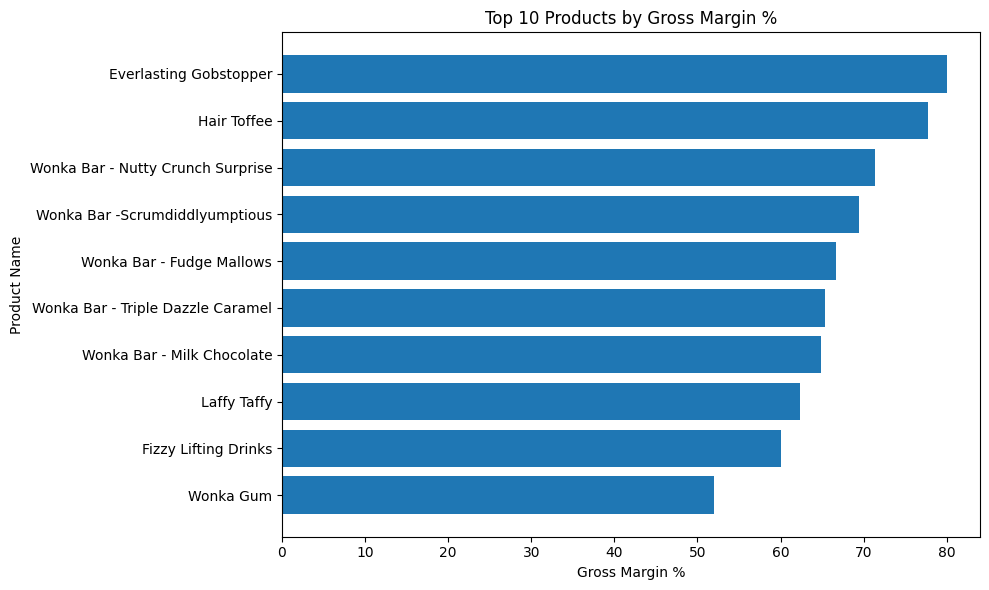

In [5]:
#charts 
plt.figure(figsize=(10, 6))
plt.barh(top_margin_products["product_name"], top_margin_products["gross_margin_pct"])
plt.xlabel("Gross Margin %")
plt.ylabel("Product Name")
plt.title("Top 10 Products by Gross Margin %")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/top_10_products_by_margin.png")
plt.show()

Low-margin high-sales products

In [6]:
low_margin_high_sales = product_summary[
    (product_summary["sales"] > product_summary["sales"].median()) &
    (product_summary["gross_margin_pct"] < product_summary["gross_margin_pct"].median())
].sort_values("sales", ascending=False)

low_margin_high_sales.head(10)

,product_id,product_name,division,sales,cost,gross_profit,units,total_orders,gross_margin_pct,profit_per_unit,revenue_contribution_pct,profit_contribution_pct,profit_rank,margin_rank,product_segment
8,OTH-LIC-15000,Lickable Wallpaper,Other,7860.00,3930.0,3930.00,393,92,50.000000,10.00,5.543658,4.205782,6.0,11.0,High Sales Low Margin
7,OTH-KAZ-38000,Kazookles,Other,1205.75,1113.0,92.75,371,94,7.692308,0.25,0.850416,0.099259,9.0,15.0,High Sales Low Margin


In [10]:
low_margin_high_sales.to_csv("D:/nassau_profitability_project/outputs/tables/low_margin_high_sales_products.csv", index=False)

Division performance chart

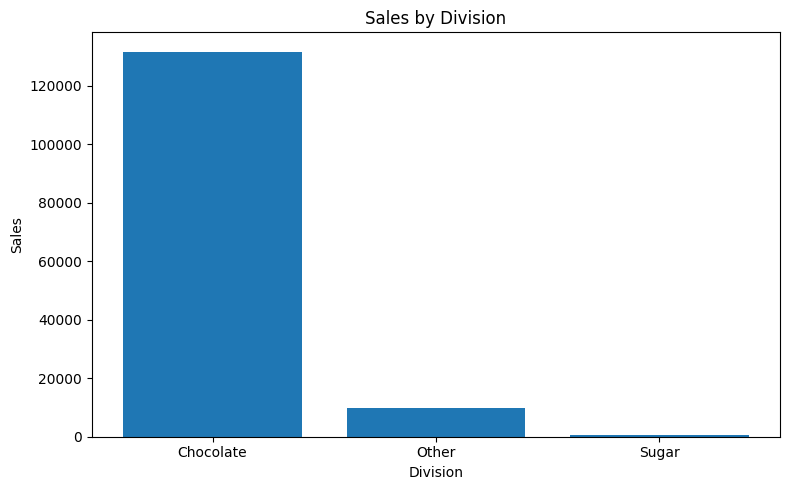

In [7]:
# Sales by divison \
plt.figure(figsize=(8, 5))
plt.bar(division_summary["division"], division_summary["sales"])
plt.xlabel("Division")
plt.ylabel("Sales")
plt.title("Sales by Division")
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/sales_by_division.png")
plt.show()

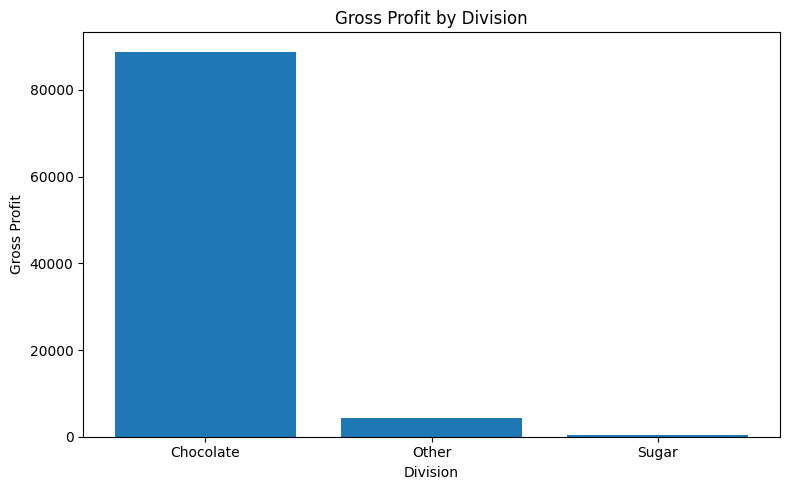

In [9]:
#Profit by Divison
plt.figure(figsize=(8, 5))
plt.bar(division_summary["division"], division_summary["gross_profit"])
plt.xlabel("Division")
plt.ylabel("Gross Profit")
plt.title("Gross Profit by Division")
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/profit_by_division.png")
plt.show()

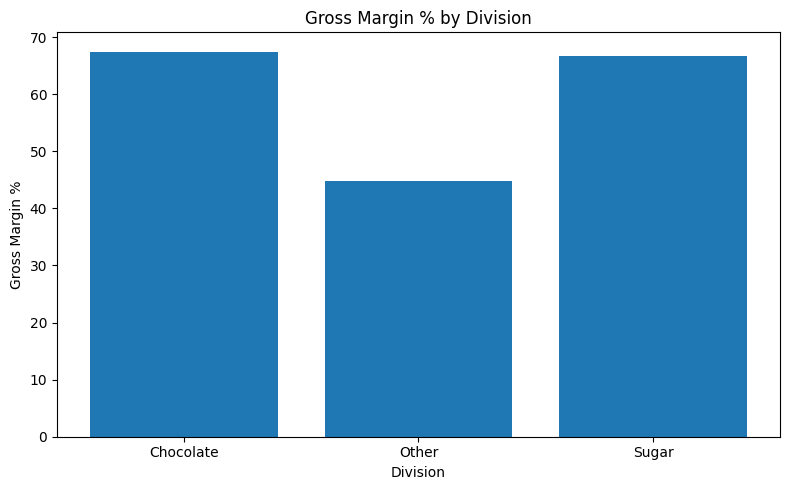

In [10]:
# Margin by divison

plt.figure(figsize=(8, 5))
plt.bar(division_summary["division"], division_summary["gross_margin_pct"])
plt.xlabel("Division")
plt.ylabel("Gross Margin %")
plt.title("Gross Margin % by Division")
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/margin_by_division.png")
plt.show()

Revenue vs profit contribution by division

In [11]:
division_compare = division_summary[["division", "revenue_contribution_pct", "profit_contribution_pct"]]
division_compare

,division,revenue_contribution_pct,profit_contribution_pct
0,Chocolate,92.883008,95.057747
1,Other,6.815491,4.637543
2,Sugar,0.301502,0.304710


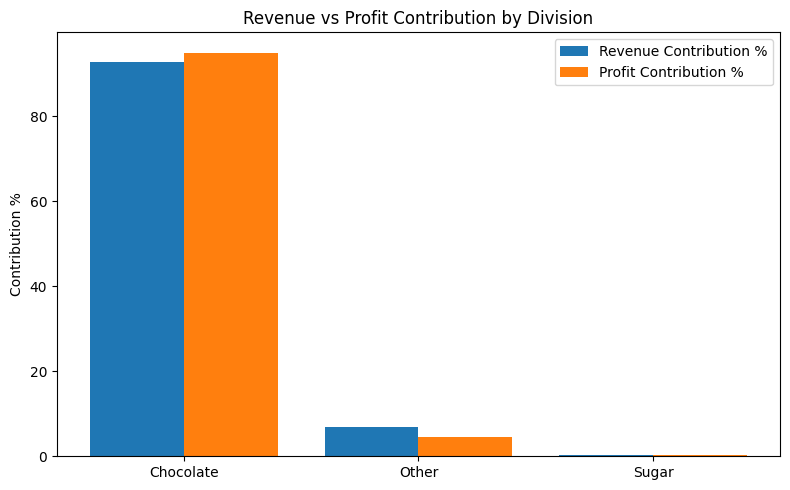

In [13]:
# Chart
x = range(len(division_compare))

plt.figure(figsize=(8, 5))
plt.bar(x, division_compare["revenue_contribution_pct"], width=0.4, label="Revenue Contribution %")
plt.bar([i + 0.4 for i in x], division_compare["profit_contribution_pct"], width=0.4, label="Profit Contribution %")
plt.xticks([i + 0.2 for i in x], division_compare["division"])
plt.ylabel("Contribution %")
plt.title("Revenue vs Profit Contribution by Division")
plt.legend()
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/revenue_vs_profit_division.png")
plt.show()

Pareto analysis for revenue

In [14]:
# sort product by sales 
pareto_revenue = product_summary.sort_values("sales", ascending=False).reset_index(drop=True)
pareto_revenue["cumulative_sales"] = pareto_revenue["sales"].cumsum()
pareto_revenue["cumulative_sales_pct"] = (pareto_revenue["cumulative_sales"] / pareto_revenue["sales"].sum()) * 100
pareto_revenue.head()

,product_id,product_name,division,sales,cost,gross_profit,units,total_orders,gross_margin_pct,profit_per_unit,revenue_contribution_pct,profit_contribution_pct,profit_rank,margin_rank,product_segment,cumulative_sales,cumulative_sales_pct
0,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,9874.80,18610.20,7596,1677,65.333333,2.45,20.090472,19.916141,2.0,6.0,Star Product,28485.00,20.090472
1,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,8517.30,19357.50,7743,1704,69.444444,2.50,19.660098,20.715882,1.0,4.0,Star Product,56359.80,39.750569
2,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,9424.38,17443.37,8267,1768,64.923077,2.11,18.949825,18.667431,3.0,7.0,Star Product,83227.55,58.700394
3,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,8296.80,16593.60,6914,1527,66.666667,2.40,17.555200,17.758030,5.0,5.0,Star Product,108117.95,76.255595
4,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755.00,16819.95,6755,1529,71.346705,2.49,16.627413,18.000263,4.0,3.0,Star Product,131692.90,92.883008


In [15]:
#Find products contributing 80% revenue
revenue_80 = pareto_revenue[pareto_revenue["cumulative_sales_pct"] <= 80]
print("Products contributing 80% of revenue:", revenue_80.shape[0])

Products contributing 80% of revenue: 4


In [16]:
pareto_revenue.to_csv("D:/nassau_profitability_project/outputs/tables/pareto_revenue_table.csv", index=False)

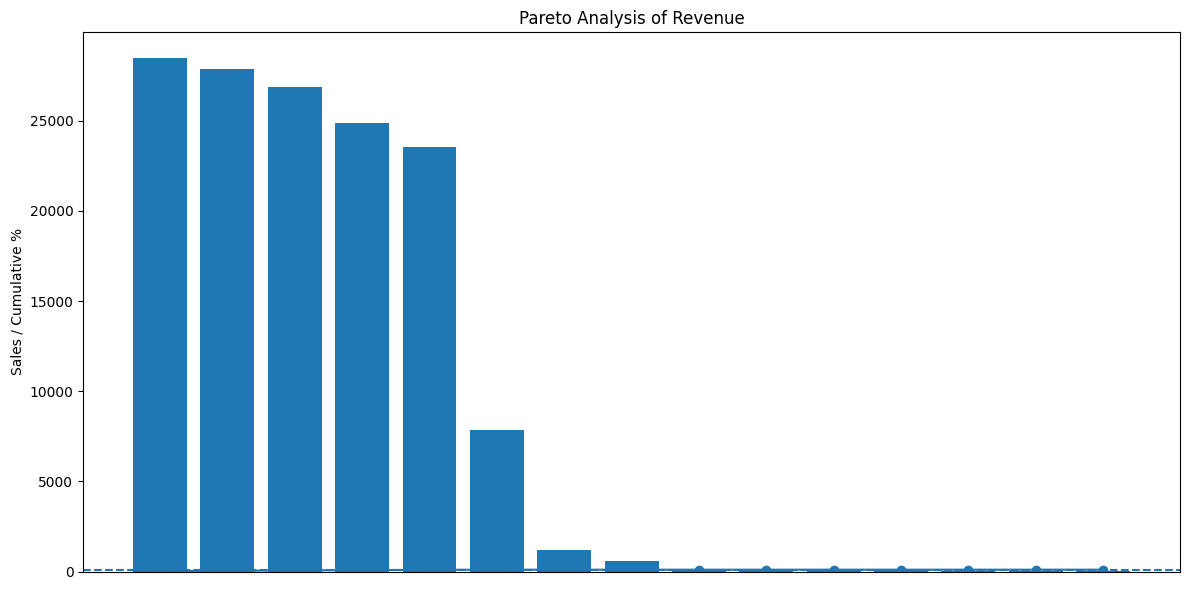

In [17]:
# charts 
plt.figure(figsize=(12, 6))
plt.bar(pareto_revenue["product_name"], pareto_revenue["sales"])
plt.plot(pareto_revenue["cumulative_sales_pct"].values, marker="o")
plt.axhline(80, linestyle="--")
plt.xticks([], [])
plt.ylabel("Sales / Cumulative %")
plt.title("Pareto Analysis of Revenue")
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/pareto_revenue.png")
plt.show()

Pareto analysis for profit

In [18]:
pareto_profit = product_summary.sort_values("gross_profit", ascending=False).reset_index(drop=True)
pareto_profit["cumulative_profit"] = pareto_profit["gross_profit"].cumsum()
pareto_profit["cumulative_profit_pct"] = (pareto_profit["cumulative_profit"] / pareto_profit["gross_profit"].sum()) * 100
pareto_profit.head()

,product_id,product_name,division,sales,cost,gross_profit,units,total_orders,gross_margin_pct,profit_per_unit,revenue_contribution_pct,profit_contribution_pct,profit_rank,margin_rank,product_segment,cumulative_profit,cumulative_profit_pct
0,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,8517.30,19357.50,7743,1704,69.444444,2.50,19.660098,20.715882,1.0,4.0,Star Product,19357.50,20.715882
1,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,9874.80,18610.20,7596,1677,65.333333,2.45,20.090472,19.916141,2.0,6.0,Star Product,37967.70,40.632023
2,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,9424.38,17443.37,8267,1768,64.923077,2.11,18.949825,18.667431,3.0,7.0,Star Product,55411.07,59.299454
3,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755.00,16819.95,6755,1529,71.346705,2.49,16.627413,18.000263,4.0,3.0,Star Product,72231.02,77.299717
4,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,8296.80,16593.60,6914,1527,66.666667,2.40,17.555200,17.758030,5.0,5.0,Star Product,88824.62,95.057747


In [19]:
#Find products contributing 80% profit:
profit_80 = pareto_profit[pareto_profit["cumulative_profit_pct"] <= 80]
print("Products contributing 80% of profit:", profit_80.shape[0])

Products contributing 80% of profit: 4


In [20]:
pareto_profit.to_csv("D:/nassau_profitability_project/outputs/tables/pareto_profit_table.csv", index=False)

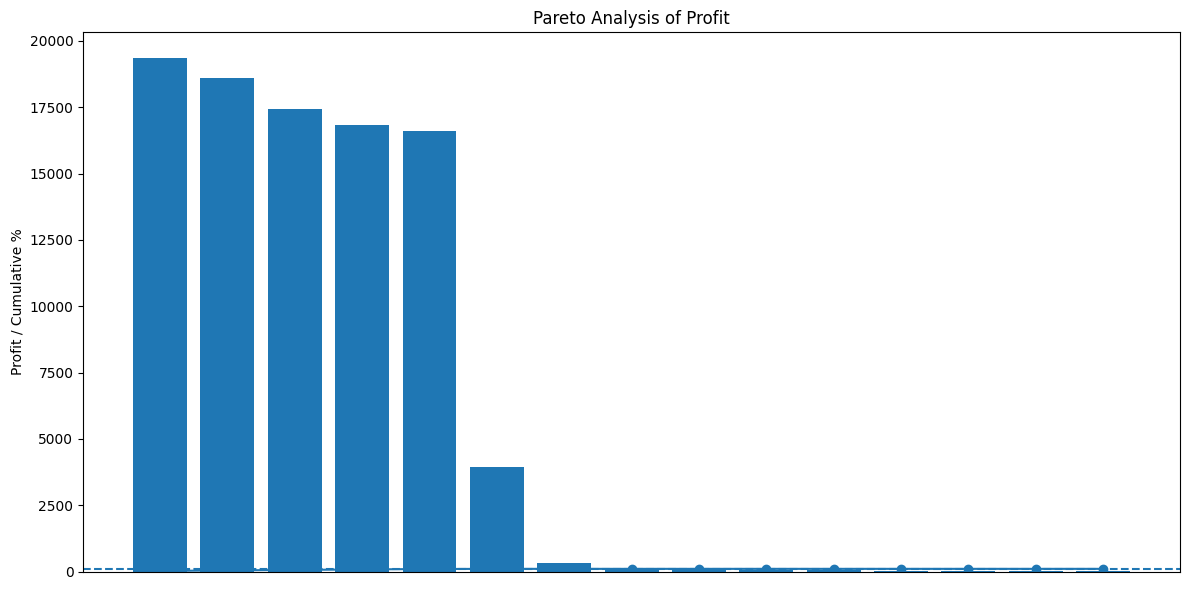

In [ ]:
# charts 
plt.figure(figsize=(12, 6))
plt.bar(pareto_profit["product_name"], pareto_profit["gross_profit"])
plt.plot(pareto_profit["cumulative_profit_pct"].values, marker="o")
plt.axhline(80, linestyle="--")
plt.xticks([], [])
plt.ylabel("Profit / Cumulative %")
plt.title("Pareto Analysis of Profit")
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/pareto_profit.png")
plt.show()

Cost vs sales scatter plot


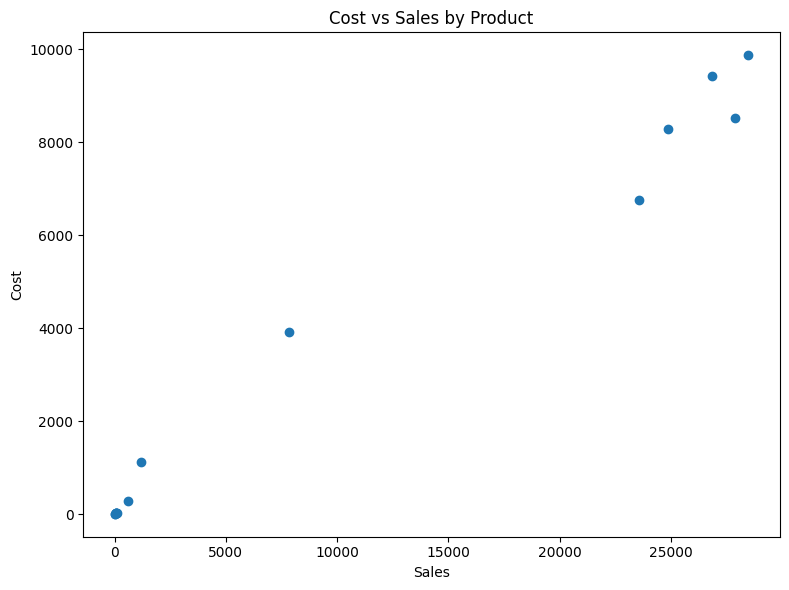

In [22]:
#This helps detect cost-heavy products.
plt.figure(figsize=(8, 6))
plt.scatter(product_summary["sales"], product_summary["cost"])
plt.xlabel("Sales")
plt.ylabel("Cost")
plt.title("Cost vs Sales by Product")
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/cost_vs_sales_scatter.png")
plt.show()

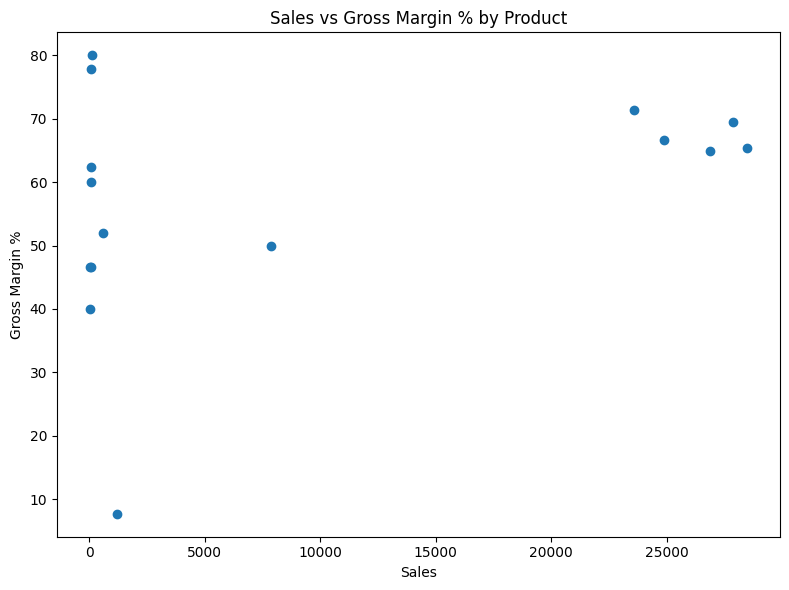

In [23]:
#Sales vs gross margin scatter plot
#This helps find high-sales low-margin products visually.
plt.figure(figsize=(8, 6))
plt.scatter(product_summary["sales"], product_summary["gross_margin_pct"])
plt.xlabel("Sales")
plt.ylabel("Gross Margin %")
plt.title("Sales vs Gross Margin % by Product")
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/sales_vs_margin_scatter.png")
plt.show()

In [24]:
#Monthly sales trend
monthly_summary = monthly_summary.sort_values("year_month")

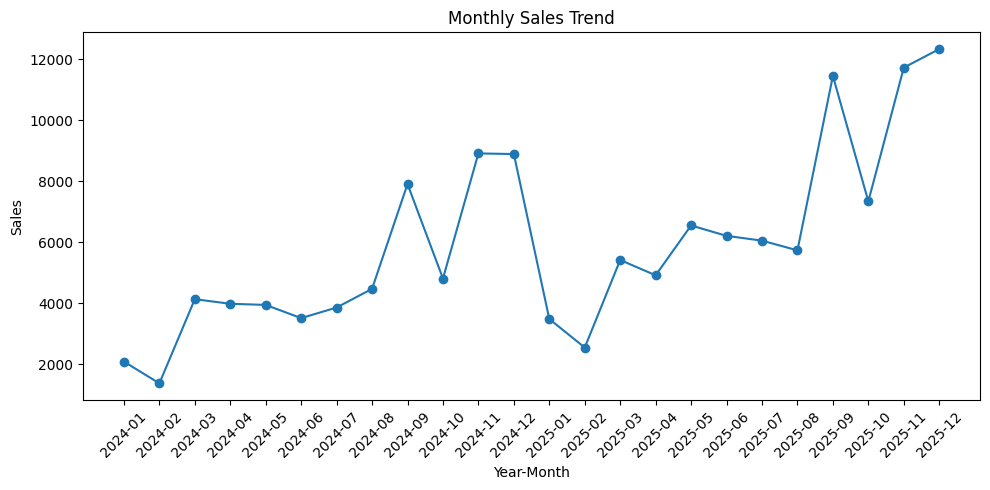

In [25]:
# sales trend 
plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["year_month"], monthly_summary["sales"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/monthly_sales_trend.png")
plt.show()

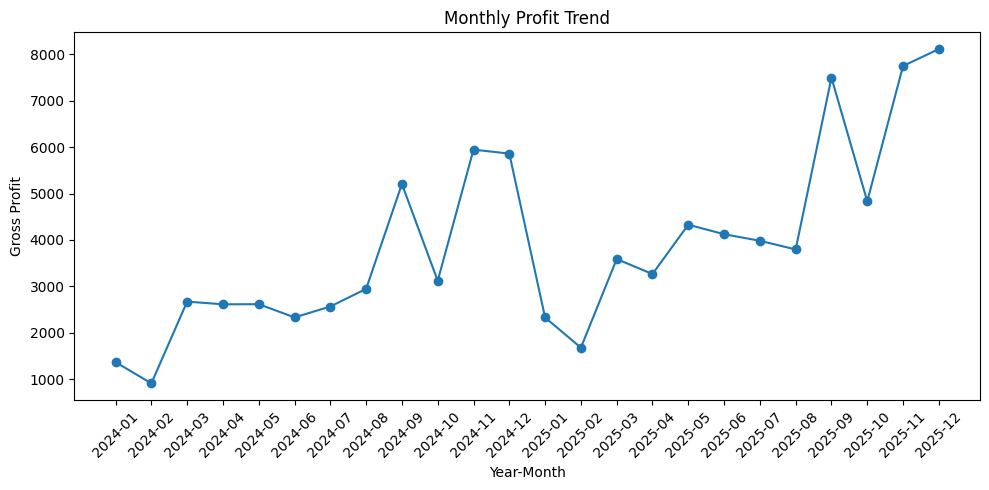

In [26]:
# profit trend 
plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["year_month"], monthly_summary["gross_profit"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Gross Profit")
plt.title("Monthly Profit Trend")
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/monthly_profit_trend.png")
plt.show()

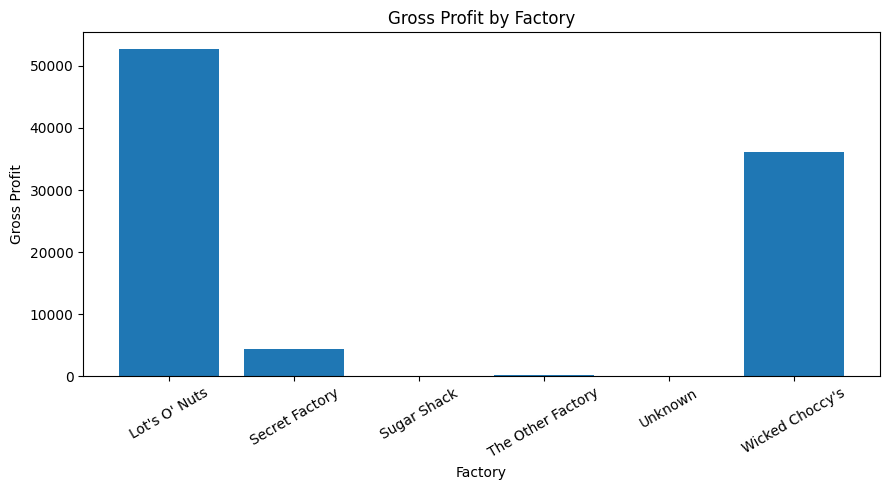

In [ ]:
# Factory performance chart 
plt.figure(figsize=(9, 5))
plt.bar(factory_summary["factory"], factory_summary["gross_profit"])
plt.xticks(rotation=30)
plt.xlabel("Factory")
plt.ylabel("Gross Profit")
plt.title("Gross Profit by Factory")
plt.tight_layout()
plt.savefig("D:/nassau_profitability_project/outputs/charts/profit_by_factory.png")
plt.show()

In [28]:
# top 10 profit product
top_profit_products = (
    df.groupby("product_name")["gross_profit"]
    .sum()
    .reset_index()
)

In [29]:
# sort by profit 
top_profit_products = top_profit_products.sort_values(
    by="gross_profit", ascending=False
)

In [30]:
top_profit_products = top_profit_products.head(10)

Build Key Insight tables 

In [31]:
# top 10 profit product 
top_profit_products.to_csv("D:/nassau_profitability_project/outputs/tables/top_10_profit_products.csv", index=False)

In [32]:
# top margin products 
top_margin_products.to_csv("D:/nassau_profitability_project/outputs/tables/top_10_margin_products.csv", index=False)

In [33]:
# diovison comparison 
division_compare.to_csv("D:/nassau_profitability_project/outputs/tables/division_revenue_profit_comparison.csv", index=False)

14) Business insights you should write from this phase

After running charts, write findings like these:

Product insights
-A small number of products contribute a large share of total profit.
-Some products have high sales volume but below-average margin, indicating pricing or cost inefficiency.
-High-margin products with lower sales may represent promotion opportunities.
*Division insights
-Some divisions contribute more revenue than profit, showing financial imbalance.
-Divisions with stronger gross margin are more efficient even if total sales are lower.
*Pareto insights
-A limited set of products contributes 80% of revenue.
-Profit is often even more concentrated than revenue, indicating dependency risk.
*Cost insights
-Some products have costs very close to sales, leaving weak profitability.
-These products may require repricing or supplier renegotiation.
*Trend insights
-Monthly sales and profit trends help identify stable and unstable periods.
-Margin volatility may indicate inconsistent pricing or cost structure.